----

PASO 1

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st

In [3]:
df= pd.read_csv('/datasets/games.csv')
print(df.info(max_cols=12))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB
None


In [4]:
print(df.head())

                       Name Platform  Year_of_Release         Genre  NA_sales  \
0                Wii Sports      Wii           2006.0        Sports     41.36   
1         Super Mario Bros.      NES           1985.0      Platform     29.08   
2            Mario Kart Wii      Wii           2008.0        Racing     15.68   
3         Wii Sports Resort      Wii           2009.0        Sports     15.61   
4  Pokemon Red/Pokemon Blue       GB           1996.0  Role-Playing     11.27   

   EU_sales  JP_sales  Other_sales  Critic_Score User_Score Rating  
0     28.96      3.77         8.45          76.0          8      E  
1      3.58      6.81         0.77           NaN        NaN    NaN  
2     12.76      3.79         3.29          82.0        8.3      E  
3     10.93      3.28         2.95          80.0          8      E  
4      8.89     10.22         1.00           NaN        NaN    NaN  


In [5]:
print(df[df['Name'].isna()])

      Name Platform  Year_of_Release Genre  NA_sales  EU_sales  JP_sales  \
659    NaN      GEN           1993.0   NaN      1.78      0.53      0.00   
14244  NaN      GEN           1993.0   NaN      0.00      0.00      0.03   

       Other_sales  Critic_Score User_Score Rating  
659           0.08           NaN        NaN    NaN  
14244         0.00           NaN        NaN    NaN  


In [6]:
print(df['User_Score'].value_counts(dropna=False).head(20))

NaN    6701
tbd    2424
7.8     324
8       290
8.2     282
8.3     254
8.5     253
7.5     251
7.9     249
8.1     244
7.7     240
7.3     236
8.4     223
7.6     220
7       220
7.4     215
8.6     211
6.8     197
8.7     188
8.8     186
Name: User_Score, dtype: int64


In [7]:
print(df.duplicated().sum())

0


In [8]:
print(df['Rating'].value_counts(dropna=False))

NaN     6766
E       3990
T       2961
M       1563
E10+    1420
EC         8
RP         3
K-A        3
AO         1
Name: Rating, dtype: int64



Problema: 

Hay valores NaN en diferentes columnas. 

En la columnas Name y Genre solo existen 2,como son muy pocos casos (2 de 16715 ≈ 0.01%), eliminarlos no afecta el análisis y es más limpio.

Tienen muchísimos NaN (más de la mitad en Critic_Score, más del 40% en User_Score y Rating. Rellenar con la media introduce valores artificiales y reduce la varianza por lo que no podemos eliminar los valores NaN.

La columna User_Score está en object porque mezcla números con cadenas como "tbd" (to be determined, 2424 entries ). Para poder hacer cálculos después (promedios, correlaciones, etc.) necesitamos convertirla a float.

Rating como usa str, los NaN podemos sustituir con "Unknown".

La columna Year_of_Release tiene 731 filas si las removemos qutaríamos el 1.61 % de los datos (consultar con la empresa). No considero que sea un % significativo, pero podemos crear una copia para hacer calculos que requieran el año. 

Hay que convertir todas las columnas a snake_case. 


PASO 2


In [9]:
############

In [10]:
df.columns = (df.columns
              .str.strip()
              .str.lower()
              .str.replace(' ', '_')
              .str.replace('-', '_'))

print(list(df.columns))


['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating']


In [11]:
df = df.dropna(subset=['name', 'genre'])
print(df.info(max_cols=12))

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16713 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16713 non-null  object 
 2   year_of_release  16444 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16713 non-null  float64
 5   eu_sales         16713 non-null  float64
 6   jp_sales         16713 non-null  float64
 7   other_sales      16713 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.5+ MB
None


In [12]:
df['rating'] = df['rating'].fillna('Unknown')
print(df['rating'].sample(5))

924      Unknown
7735           T
14612    Unknown
8225           E
14880    Unknown
Name: rating, dtype: object


In [13]:
df['user_score'] = pd.to_numeric(df['user_score'], errors='coerce')

print(df['user_score'].dtype)
print(df['user_score'].isna().sum())

float64
9123


In [14]:
print(df.info(max_cols=12))
print(df.head())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16713 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16713 non-null  object 
 2   year_of_release  16444 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16713 non-null  float64
 5   eu_sales         16713 non-null  float64
 6   jp_sales         16713 non-null  float64
 7   other_sales      16713 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           16713 non-null  object 
dtypes: float64(7), object(4)
memory usage: 1.5+ MB
None
                       name platform  year_of_release         genre  na_sales  \
0                Wii Sports      Wii           2006.0        Sports     41.36   
1         Super Mario Bros.      NES           1985.0      Platform     29

In [15]:
#copia
df_year = df.dropna(subset=['year_of_release']).copy()

df_year['year_of_release'] = df_year['year_of_release'].astype(int)

print(df_year['year_of_release'].dtype)
print('df original: ',len(df),', df copia: ', len(df_year))  
print()
print(df_year.info(max_cols=12))

int64
df original:  16713 , df copia:  16444

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16444 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16444 non-null  object 
 1   platform         16444 non-null  object 
 2   year_of_release  16444 non-null  int64  
 3   genre            16444 non-null  object 
 4   na_sales         16444 non-null  float64
 5   eu_sales         16444 non-null  float64
 6   jp_sales         16444 non-null  float64
 7   other_sales      16444 non-null  float64
 8   critic_score     7983 non-null   float64
 9   user_score       7463 non-null   float64
 10  rating           16444 non-null  object 
dtypes: float64(6), int64(1), object(4)
memory usage: 1.5+ MB
None


In [16]:
df_year.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,Unknown
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,Unknown


In [17]:
region_cols = ['na_sales', 'eu_sales', 'jp_sales', 'other_sales']

df['global_sales'] = df[region_cols].sum(axis=1, min_count=1)

print(df[['name','platform'] + region_cols + ['global_sales']].head())
print(df['global_sales'].describe())

                       name platform  na_sales  eu_sales  jp_sales  \
0                Wii Sports      Wii     41.36     28.96      3.77   
1         Super Mario Bros.      NES     29.08      3.58      6.81   
2            Mario Kart Wii      Wii     15.68     12.76      3.79   
3         Wii Sports Resort      Wii     15.61     10.93      3.28   
4  Pokemon Red/Pokemon Blue       GB     11.27      8.89     10.22   

   other_sales  global_sales  
0         8.45         82.54  
1         0.77         40.24  
2         3.29         35.52  
3         2.95         32.77  
4         1.00         31.38  
count    16713.000000
mean         0.533315
std          1.548282
min          0.000000
25%          0.060000
50%          0.170000
75%          0.470000
max         82.540000
Name: global_sales, dtype: float64


PASO 3

Preparación

In [18]:
########################

In [19]:
df_year['global_sales'] = df.loc[df_year.index, 'global_sales']

2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
Name: year_of_release, dtype: int64


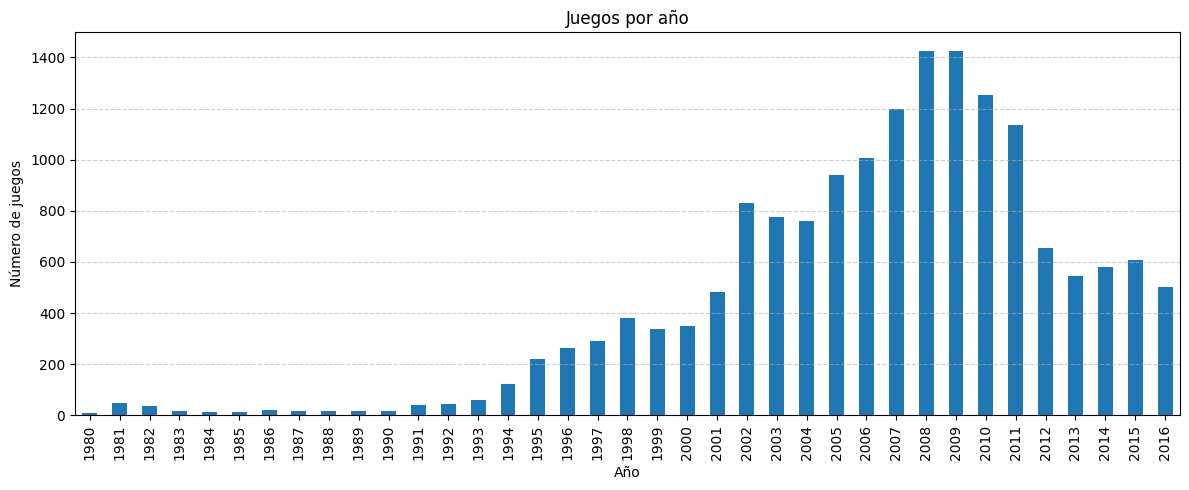

Años con < 50 juegos: [1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992]


In [20]:
#3.1
yr_counts = df_year['year_of_release'].value_counts().sort_index()
print(yr_counts.tail(10))  # últimos 10 años



yr_counts.plot(kind='bar', figsize=(12,5))
plt.title('Juegos por año')
plt.xlabel('Año')
plt.ylabel('Número de juegos')
plt.grid(True, axis='y', linestyle='--', linewidth=0.8, alpha=0.6)
plt.tight_layout()
plt.show()


umbral = 50
pocos = yr_counts[yr_counts < umbral]
print(f"Años con < {umbral} juegos:", list(pocos.index))


Top plataformas por ventas: ['PS2', 'X360', 'PS3', 'Wii', 'DS', 'PS', 'PS4']


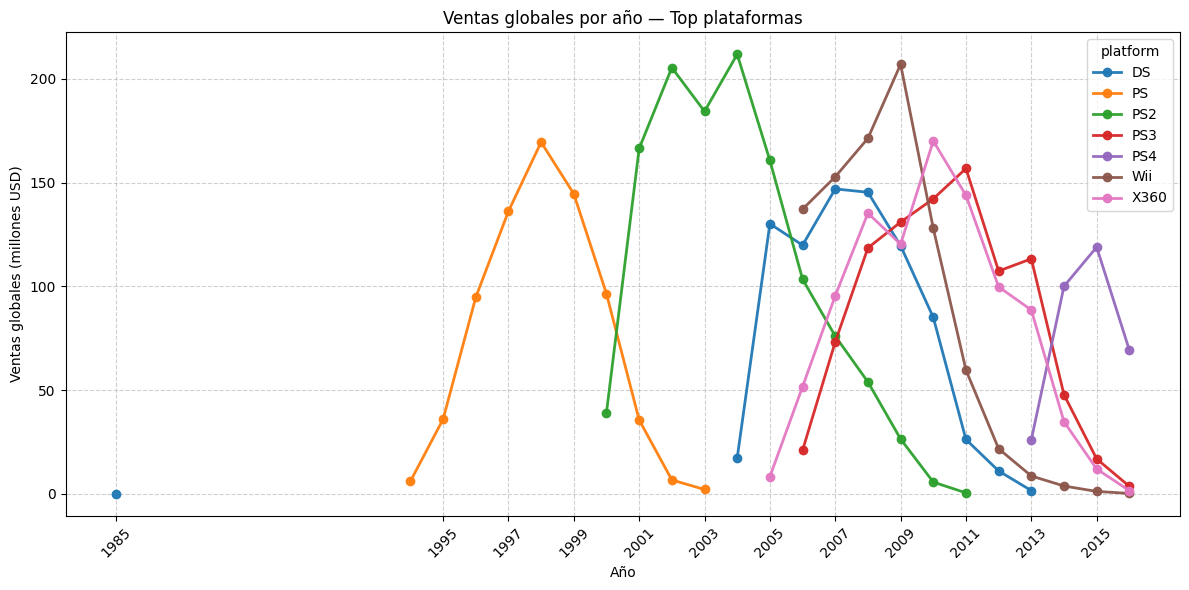

In [21]:
#3.2

# top plataformas por ventas totales
topN = 7
#top_plats = df_year.groupby('platform')['global_sales'].sum().nlargest(topN).index

top_plats = (df_year.groupby('platform')['global_sales']
             .sum()
             .sort_values(ascending=False)
             .head(topN)
             .index)


print("Top plataformas por ventas:", list(top_plats))



annual = (df_year[df_year['platform'].isin(top_plats)]
          .groupby(['year_of_release','platform'])['global_sales']
          .sum()
          .reset_index()
          .pivot(index='year_of_release', columns='platform', values='global_sales')
          .sort_index())



annual.plot(figsize=(12, 6),
            marker='o',
            linewidth=2,
            alpha=0.95)

plt.title('Ventas globales por año — Top plataformas')
plt.xlabel('Año')
plt.ylabel('Ventas globales (millones USD)')
plt.grid(True, axis='both', linestyle='--', linewidth=0.8, alpha=0.6)

years = annual.index.to_numpy()
step = 2 if len(years) > 20 else 1
plt.xticks(years[::step], rotation=45)

plt.tight_layout()
plt.show()



In [22]:
#3.3

last = df_year['year_of_release'].max()
recent_window = 3
corte = last - (recent_window - 1)

earlier = df_year[df_year['year_of_release'] < corte]
recent  = df_year[df_year['year_of_release'] >= corte]

earlier_tot = (earlier.groupby('platform')['global_sales']
               .sum().sort_values(ascending=False))

recent_tot  = recent.groupby('platform')['global_sales'].sum()

still_active = recent_tot[recent_tot > 0].index

ex_populares = earlier_tot.index.difference(still_active)

#print(f"Ex-populares (sin ventas en {last-(recent_window-1)}–{last}):", list(ex_populares[:10]))
print(f"Ex-populares (sin ventas en {corte}–{last}):", list(ex_populares))


Ex-populares (sin ventas en 2014–2016): ['2600', '3DO', 'DC', 'DS', 'GB', 'GBA', 'GC', 'GEN', 'GG', 'N64', 'NES', 'NG', 'PCFX', 'PS', 'PS2', 'SAT', 'SCD', 'SNES', 'TG16', 'WS', 'XB']


In [23]:
#3.4

#(2016 puede estar incompleto)
df_model = df_year[df_year['year_of_release'].between(2013, 2016)]

print("Años elegidos:", sorted(df_model['year_of_release'].unique()))
print("Suma de las filas de los años:", len(df_model))


Años elegidos: [2013, 2014, 2015, 2016]
Suma de las filas de los años: 2233


In [24]:
#3.5

# líderes por ventas
leaders = df_model.groupby('platform')['global_sales'].sum().sort_values(ascending=False)
print("Líderes (ventas 2013–2016):")
print(leaders.head(10))

# tendencia simple: ventas 2016 - ventas 2013

plat_year = (df_model.groupby(['platform','year_of_release'])['global_sales']
             .sum().unstack().fillna(0))


trend = plat_year[2016] - plat_year[2013]

print("\nTendencia (2016 - 2013): positiva=crece, negativa=cae")
print(trend.sort_values(ascending=False).head(10))


Líderes (ventas 2013–2016):
platform
PS4     314.14
PS3     181.43
XOne    159.32
3DS     143.25
X360    136.80
WiiU     64.63
PC       39.43
PSV      32.99
Wii      13.66
PSP       3.50
Name: global_sales, dtype: float64

Tendencia (2016 - 2013): positiva=crece, negativa=cae
platform
PS4     43.26
XOne     7.19
DS      -1.54
PSP     -3.14
PSV     -6.34
PC      -7.13
Wii     -8.41
WiiU   -17.05
3DS    -41.43
X360   -87.06
dtype: float64


<Figure size 1200x600 with 0 Axes>

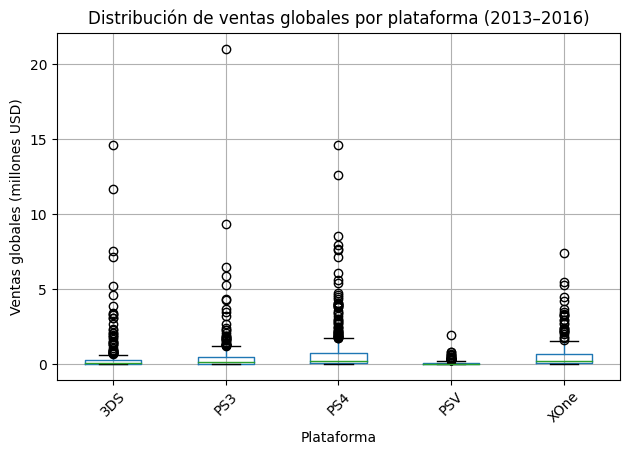

In [25]:
#3.6

counts = df_model['platform'].value_counts()
valid_plats = counts[counts >= 200].index  # en esta linea se ajusta la cantidad de juegos

plt.figure(figsize=(12,6))
df_model[df_model['platform'].isin(valid_plats)].boxplot(column='global_sales', by='platform', rot=45)
plt.title('Distribución de ventas globales por plataforma (2013–2016)')
plt.suptitle('')
plt.xlabel('Plataforma'); plt.ylabel('Ventas globales (millones USD)')
plt.tight_layout()
plt.show()


HALLAZGOS

Las ventas por juego están muy sesgadas a la derecha (muchísimos juegos venden poco y unos pocos venden muchísimo).

Algunas plataformas (PS3,PS4,3DS) tienen picos de 15–22 millones (juegos “mega-hits”), mientras la mayoría está <1M.

Pensaría que Xbox One tendría más juegos arriba de 5m por ser competencia directa de Play Station, pero no es el caso. Aunque no se queda tan lejos. 


Plataforma analizada: PS4
              user_score  critic_score  global_sales
user_score      1.000000      0.557654     -0.031957
critic_score    0.557654      1.000000      0.406568
global_sales   -0.031957      0.406568      1.000000


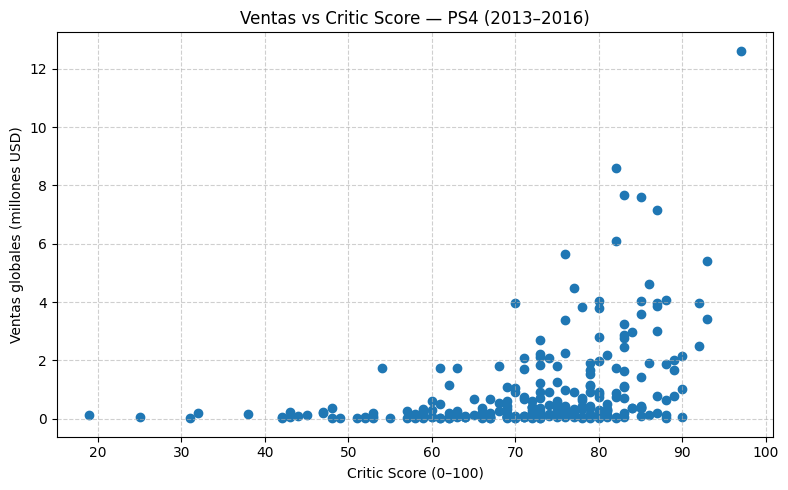

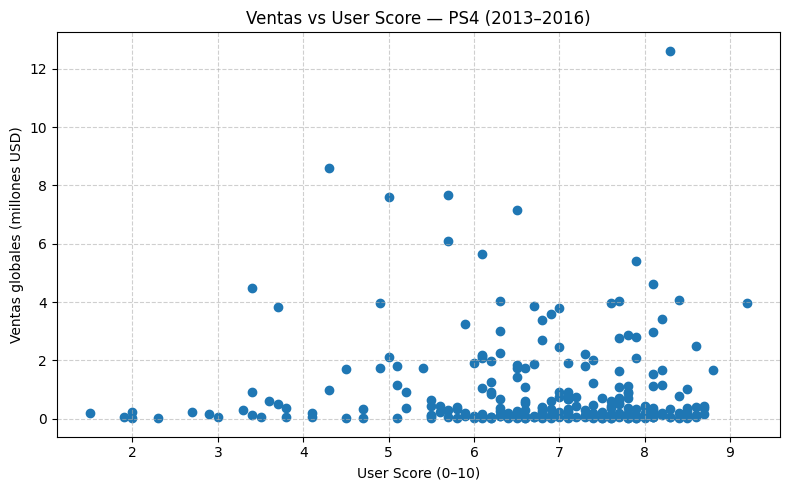

In [26]:
#3.7

pop_platform = leaders.idxmax()  # la de mayores ventas en 2013–2016
df_pop = df_model[df_model['platform'] == pop_platform].copy() #copia de seguridad

print("Plataforma analizada:", pop_platform)
print(df_pop[['user_score','critic_score','global_sales']].corr())

# críticos vs ventas
plt.figure(figsize=(8,5))
plt.scatter(df_pop['critic_score'], df_pop['global_sales'])
plt.title(f'Ventas vs Critic Score — {pop_platform} (2013–2016)')
plt.xlabel('Critic Score (0–100)'); plt.ylabel('Ventas globales (millones USD)')
plt.grid(True, linestyle='--', linewidth=0.8, alpha=0.6)
plt.tight_layout(); plt.show()

# usuarios vs ventas
plt.figure(figsize=(8,5))
plt.scatter(df_pop['user_score'], df_pop['global_sales'])
plt.title(f'Ventas vs User Score — {pop_platform} (2013–2016)')
plt.xlabel('User Score (0–10)'); plt.ylabel('Ventas globales (millones USD)')
plt.grid(True, linestyle='--', linewidth=0.8, alpha=0.6)
plt.tight_layout(); plt.show()


CONCLUSIONES 

PS4

Critic Score si hay una relación: mejores críticas + probabilidad de ventas altas. No garantizan un éxito, pero ayudan.

En User Score no se ve una relación fuerte, esto puede ser gracias a que el User Score viene después de que probar el juego. Pueden vender mucho en el lanzamiento por el hype, pero ya después de jugarlo la gente puede encontrarlo aburrido o algún otro tema negativo. 






In [27]:
#3.8

# juegos multiplataforma en el periodo
multi_names = (df_model.groupby('name')['platform'].nunique())
multi_names = multi_names[multi_names > 1].index

# tabla nombre x plataforma con ventas 
multi_tab = (df_model[df_model['name'].isin(multi_names)]
             .pivot_table(index='name',
                          columns='platform',
                          values='global_sales',
                          aggfunc='sum'))

# resumen por plataforma (mediana, media y cantidad de títulos multi)
res_multi = (df_model[df_model['name'].isin(multi_names)]
             .groupby('platform')['global_sales']
             .agg(mean='mean', median='median', count='count')
             .sort_values('mean', ascending=False)
             .round(2))

print(res_multi)


          mean  median  count
platform                     
PS4       0.88    0.26    316
X360      0.75    0.27    180
Wii       0.62    0.18     22
XOne      0.60    0.22    224
PS3       0.59    0.20    277
3DS       0.33    0.12     62
WiiU      0.32    0.12     70
PC        0.21    0.10    130
DS        0.19    0.15      8
PSV       0.13    0.09    140
PSP       0.10    0.08     14


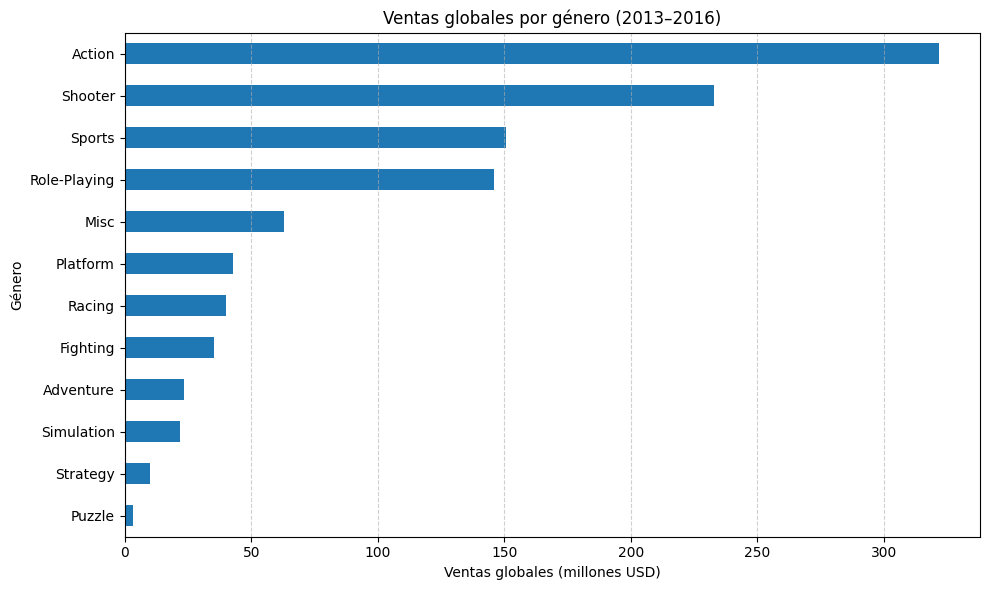

In [63]:
#3.9

genre_sales = df_model.groupby('genre')['global_sales'].sum().sort_values()

genre_sales.plot(kind='barh', figsize=(10,6))
plt.title('Ventas globales por género (2013–2016)')
plt.xlabel('Ventas globales (millones USD)')
plt.ylabel('Género')
plt.grid(True, axis='x', linestyle='--', linewidth=0.8, alpha=0.6)
plt.tight_layout()
plt.show()


Definitivamente los juegos de acción y shooters predominan, seguidos de los juegos de deportes y juegos de rol. 
Se pensaría que los juegos de carreras tendrían un mayor impacto, pero los datos demuestran lo contrario con menos de 50 millones de dls en ventas. 

PASO 4

In [29]:
na_col, eu_col, jp_col = 'na_sales', 'eu_sales', 'jp_sales'

NA

In [30]:
top5_plat_NA = df_year.groupby('platform')[na_col].sum().sort_values(ascending=False).head(5)

print("Top 5 plataformas — NA (millones USD):")
print(top5_plat_NA.round(2),'\n')

share_NA = (top5_plat_NA / df_year[na_col].sum() * 100).round(1)

print("Partición de mercado de cada una en NA (% del total NA):")
print(share_NA,'\n')

Top 5 plataformas — NA (millones USD):
platform
X360    595.74
PS2     572.92
Wii     486.87
PS3     390.13
DS      380.31
Name: na_sales, dtype: float64 

Partición de mercado de cada una en NA (% del total NA):
platform
X360    13.7
PS2     13.2
Wii     11.2
PS3      9.0
DS       8.8
Name: na_sales, dtype: float64 



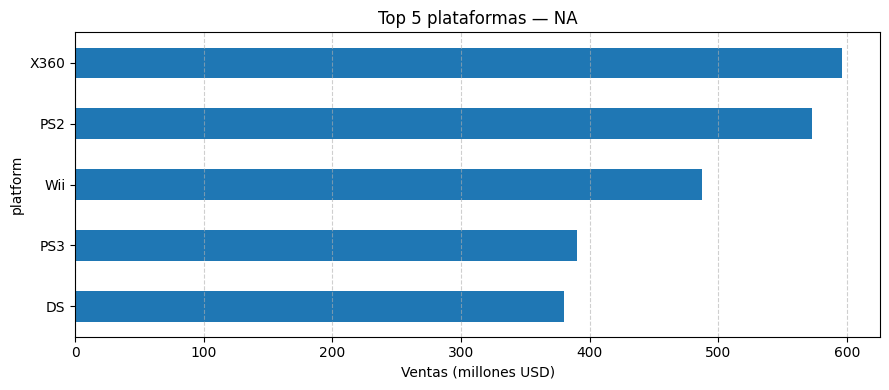

In [31]:
top5_plat_NA.sort_values().plot(kind='barh',
                                figsize=(9,4),
                                title='Top 5 plataformas — NA')

plt.xlabel('Ventas (millones USD)')
plt.grid(True, axis='x', linestyle='--', linewidth=0.8, alpha=0.6)
plt.tight_layout(); plt.show()

EU

In [44]:
top5_plat_EU = (df_year.groupby('platform')[eu_col]
                .sum().sort_values(ascending=False).head(5))

print("Top 5 plataformas — EU (millones USD):")
print(top5_plat_EU.round(2).to_string(), '\n')

share_EU = (top5_plat_EU / df_year[eu_col].sum() * 100).round(1)

print("Participación de mercado EU (% del total EU):")
print(share_EU.to_string(), '\n')



Top 5 plataformas — EU (millones USD):
platform
PS2     332.63
PS3     327.21
X360    268.32
Wii     258.32
PS      212.39 

Participación de mercado EU (% del total EU):
platform
PS2     13.9
PS3     13.6
X360    11.2
Wii     10.8
PS       8.9 



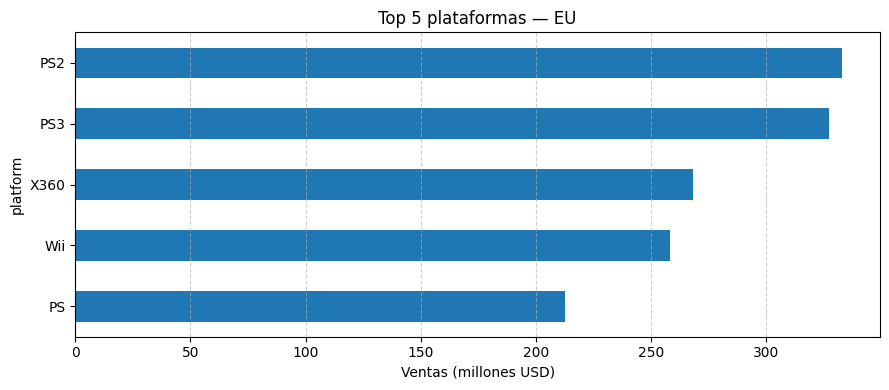

In [33]:
top5_plat_EU.sort_values().plot(kind='barh',
                                figsize=(9,4),
                                title='Top 5 plataformas — EU')

plt.xlabel('Ventas (millones USD)')
plt.grid(True, axis='x', linestyle='--', linewidth=0.8, alpha=0.6)
plt.tight_layout(); plt.show()

JP

In [45]:
top5_plat_JP = (df_year.groupby('platform')[jp_col]
                .sum().sort_values(ascending=False).head(5))

print("Top 5 plataformas — JP (millones USD):")
print(top5_plat_JP.round(2), '\n')

share_JP = (top5_plat_JP / df_year[jp_col].sum() * 100).round(1)

print("Participación de mercado JP (% del total JP):")
print(share_JP, '\n')

Top 5 plataformas — JP (millones USD):
platform
DS      175.02
PS      139.78
PS2     137.54
SNES    116.55
3DS     100.62
Name: jp_sales, dtype: float64 

Participación de mercado JP (% del total JP):
platform
DS      13.6
PS      10.8
PS2     10.7
SNES     9.0
3DS      7.8
Name: jp_sales, dtype: float64 



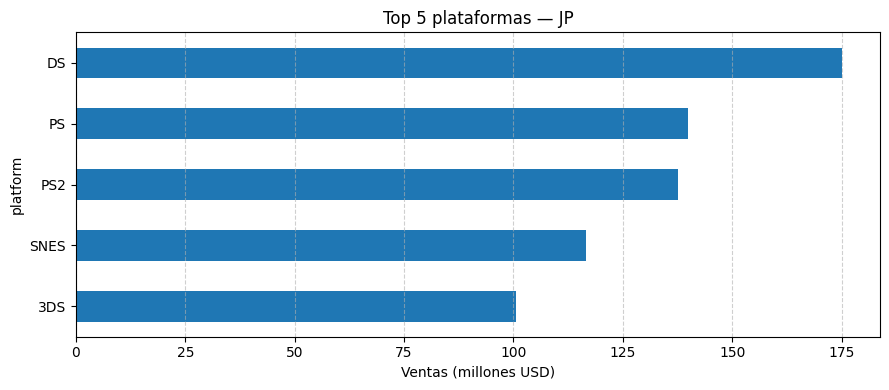

In [35]:
top5_plat_JP.sort_values().plot(kind='barh',
                                figsize=(9,4),
                                title='Top 5 plataformas — JP')

plt.xlabel('Ventas (millones USD)')
plt.grid(True, axis='x', linestyle='--', linewidth=0.8, alpha=0.6)
plt.tight_layout(); plt.show()

Tamaño del mercado: NA muestra volúmenes más altos (top ≈600 M) que EU (≈330 M) y JP (≈175 M). NA > EU > JP en ventas acumuladas de las top plataformas.

Quién domina:

NA: fuerte presencia de Xbox 360 (1º) y buenas cifras de Wii/PS2/PS3.

EU: claro liderazgo de PlayStation (PS2, PS3), X360 va detrás.

JP: no aparece Xbox, lideran Nintendo (DS, 3DS) y PlayStation clásicos. Incluso entra SNES (preferencia por portátiles y marcas locales).

Lectura general: Occidente se divide entre Sony vs Microsoft (con Nintendo fuerte en Wii/DS), mientras Japón es mucho más Nintendo/Sony y portátil, Xbox prácticamente no tiene tracción allí.

ESRB POR REGIÓN

NA

In [36]:
esrb_NA = df_year.groupby('rating')[na_col].sum().sort_values(ascending=False)

esrb_NA_pct = (esrb_NA / esrb_NA.sum() * 100).round(1)

print("Ventas por ESRB — NA (millones):\n", esrb_NA.round(2).to_string(), '\n')
print("Participación por ESRB — NA (%):\n", esrb_NA_pct.to_string(), '\n')

Ventas por ESRB — NA (millones):
 rating
E          1274.24
Unknown    1225.84
T           747.60
M           742.89
E10+        345.50
K-A           2.56
EC            1.53
AO            1.26
RP            0.00 

Participación por ESRB — NA (%):
 rating
E          29.4
Unknown    28.2
T          17.2
M          17.1
E10+        8.0
K-A         0.1
EC          0.0
AO          0.0
RP          0.0 



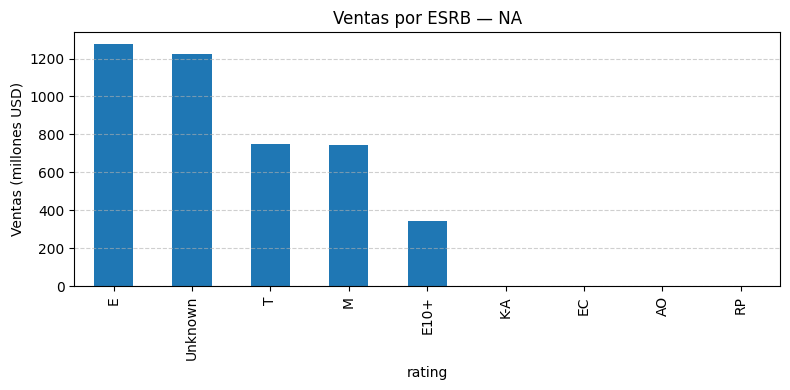

In [37]:
esrb_NA.plot(kind='bar',
             figsize=(8,4),
             title='Ventas por ESRB — NA')

plt.ylabel('Ventas (millones USD)')
plt.grid(True, axis='y', linestyle='--', linewidth=0.8, alpha=0.6)
plt.tight_layout()
plt.show()

EU

In [38]:
esrb_EU = df_year.groupby('rating')[eu_col].sum().sort_values(ascending=False)

esrb_EU_pct = (esrb_EU / esrb_EU.sum() * 100).round(1)

print("Ventas por ESRB — EU (millones):\n", esrb_EU.round(2).to_string(), '\n')
print("Participación por ESRB — EU (%):\n", esrb_EU_pct.to_string(), '\n')

Ventas por ESRB — EU (millones):
 rating
E          703.87
Unknown    609.65
M          480.00
T          421.79
E10+       183.35
AO           0.61
K-A          0.27
EC           0.11
RP           0.03 

Participación por ESRB — EU (%):
 rating
E          29.3
Unknown    25.4
M          20.0
T          17.6
E10+        7.6
AO          0.0
K-A         0.0
EC          0.0
RP          0.0 



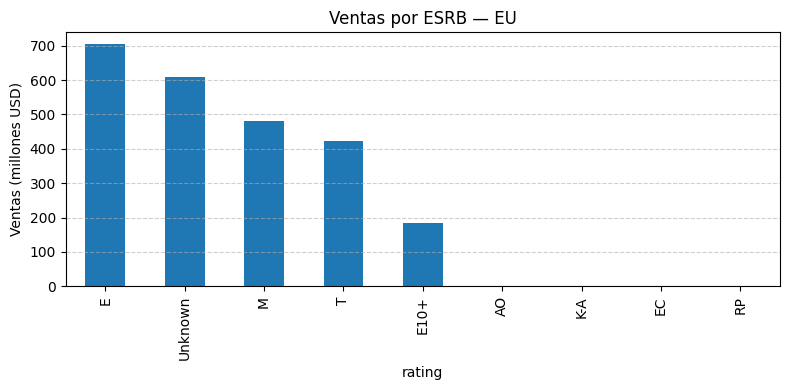

In [39]:
esrb_EU.plot(kind='bar',
             figsize=(8,4),
             title='Ventas por ESRB — EU')

plt.ylabel('Ventas (millones USD)')
plt.grid(True, axis='y', linestyle='--', linewidth=0.8, alpha=0.6)
plt.tight_layout()
plt.show()

JP

In [40]:
esrb_JP = df_year.groupby('rating')[jp_col].sum().sort_values(ascending=False)

esrb_JP_pct = (esrb_JP / esrb_JP.sum() * 100).round(1)

print("Ventas por ESRB — JP (millones):\n", esrb_JP.round(2).to_string(), '\n')
print("Participación por ESRB — JP (%):\n", esrb_JP_pct.to_string(), '\n')

Ventas por ESRB — JP (millones):
 rating
Unknown    836.74
E          197.96
T          150.70
M           63.58
E10+        40.20
K-A          1.46
AO           0.00
EC           0.00
RP           0.00 

Participación por ESRB — JP (%):
 rating
Unknown    64.8
E          15.3
T          11.7
M           4.9
E10+        3.1
K-A         0.1
AO          0.0
EC          0.0
RP          0.0 



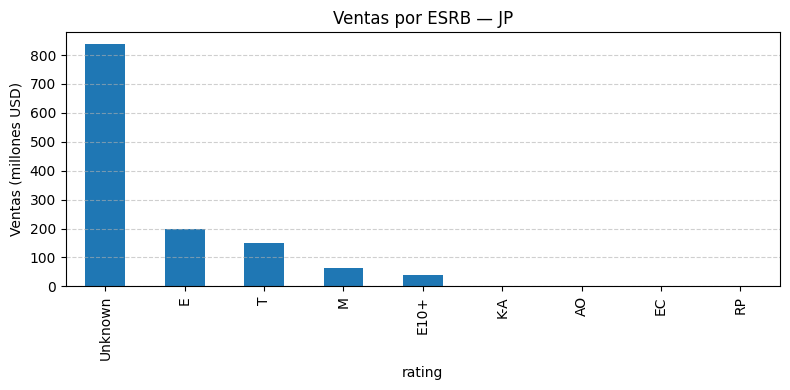

In [41]:
esrb_JP.plot(kind='bar',
             figsize=(8,4),
             title='Ventas por ESRB — JP')

plt.ylabel('Ventas (millones USD)')
plt.grid(True, axis='y', linestyle='--', linewidth=0.8, alpha=0.6)
plt.tight_layout(); plt.show()

NA: domina E (Everyone), T y M también mueven mucho volumen (mercado mixto: familiar + teen/maduro). E10+ bastante menor.

EU: patrón parecido a NA, E primero, luego Unknown, M y T cercanos entre sí, menos peso relativo de categorías maduras que en NA.

JP: “Unknown” arrasa porque ESRB casi no se usa allí (se usa CERO), así que muchos juegos quedan sin mapeo. Si ignoras “Unknown”, lidera E, y T/M quedan muy por detrás, preferencia más marcada por juegos para todo público.

PASO 5

XOne vs PC (dos colas)

H₀: μ_XOne = μ_PC (las medias de user_score son iguales)

H₁: μ_XOne ≠ μ_PC (las medias son distintas)


Formulación:
Se usa dos colas porque la instrucción pregunta si “son las mismas” (igualdad) vs “diferentes” (no igualdad), sin especificar dirección.

Prueba t de Welch para dos muestras independientes.

Por qué Welch?

-No asumimos varianzas iguales entre plataformas.

-Tolera tamaños de muestra desbalanceados.

In [54]:

alpha = 0.05

xone = df_model.loc[(df_model['platform']=='XOne') & df_model['user_score'].notna(), 'user_score']
pc   = df_model.loc[(df_model['platform']=='PC')   & df_model['user_score'].notna(), 'user_score']

print(f"Tamaños: XOne={len(xone)}, PC={len(pc)}")
print(f"Medias: XOne={xone.mean().round(2)}, PC={pc.mean().round(2)}")

t_stat, p_val = st.ttest_ind(xone, pc, equal_var=False)  # Welch

print(f"t = {t_stat.round(2)}, p = {p_val.round(2)}")

if p_val < alpha:
    print("Conclusión: Rechazamos H0 / Las medias de user_score SON diferentes (XOne vs PC)")
else:
    print("Conclusión: No rechazamos H0 / No hay evidencia de diferencia en las medias (XOne vs PC)")


Tamaños: XOne=182, PC=155
Medias: XOne=6.52, PC=6.27
t = 1.45, p = 0.15
Conclusión: No rechazamos H0 / No hay evidencia de diferencia en las medias (XOne vs PC)


Acción vs Deportes (dos colas)

*De nuevo, dos colas porque se pide comprobar si “son diferentes”.

H₀: μ_Acción = μ_Deportes

H₁: μ_Acción ≠ μ_Deportes

In [56]:
accion  = df_model.loc[(df_model['genre']=='Action')  & df_model['user_score'].notna(), 'user_score']
deportes= df_model.loc[(df_model['genre']=='Sports')  & df_model['user_score'].notna(), 'user_score']

print(f"Tamaños: Acción={len(accion)}, Deportes={len(deportes)}")
print(f"Medias:   Acción={accion.mean().round(2)}, Deportes={deportes.mean().round(2)}")

t_stat, p_val = st.ttest_ind(accion, deportes, equal_var=False)  # Welch
print(f"t = {t_stat.round(2)}, p = {p_val.round(2)}")

if p_val < alpha:
    print("Conclusión: Rechazamos H0 / Las medias de user_score SON diferentes (Acción vs Deportes)")
else:
    print("Conclusión: No rechazamos H0 / No hay evidencia de diferencia en las medias (Acción vs Deportes)")


Tamaños: Acción=389, Deportes=160
Medias:   Acción=6.84, Deportes=5.24
t = 10.23, p = 0.0
Conclusión: Rechazamos H0 / Las medias de user_score SON diferentes (Acción vs Deportes)


CONCLUSIÓN EJECUTIVA

El mercado reciente se desplaza a PS4/XOne, las ventas por juego son altamente concentradas en pocos éxitos. Las críticas profesionales aportan señal útil y existen preferencias regionales claras (Occidente vs Japón). Con esto, la mejor estrategia para 2017 es priorizar PS4/XOne, apostar por géneros líderes por región, y usar críticas de medios para afinar campañas y stock.

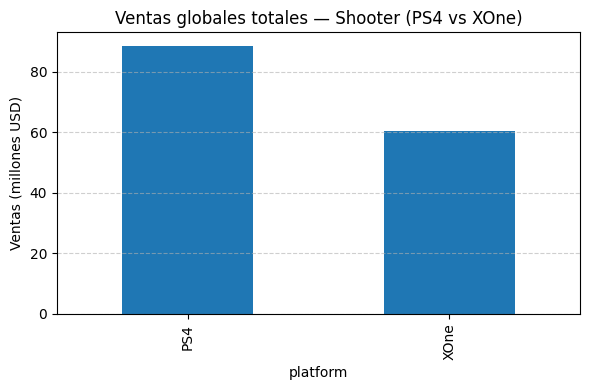

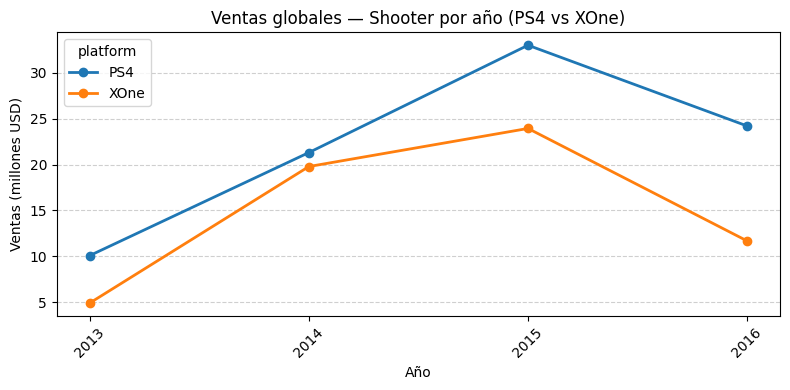

In [64]:
###### COMPARACIÓN EXTRA 



# === base de trabajo
base = df_model if 'df_model' in globals() else df_year

# === FILTRO: Shooter en PS4 y XOne
mask = (base['genre'] == 'Shooter') & (base['platform'].isin(['PS4', 'XOne']))
shoot = base[mask]

# ---------- 1) BARRAS: ventas totales (globales) ----------
totals = (shoot.groupby('platform')['global_sales']
          .sum()
          .reindex(['PS4','XOne']))   # orden fijo

totals.plot(kind='bar', figsize=(6,4), title='Ventas globales totales — Shooter (PS4 vs XOne)')
plt.ylabel('Ventas (millones USD)')
plt.grid(True, axis='y', linestyle='--', linewidth=0.8, alpha=0.6)
plt.tight_layout(); plt.show()

# ---------- 2) LÍNEAS: ventas por año ----------
annual = (shoot.groupby(['year_of_release','platform'])['global_sales']
          .sum()
          .unstack())                 # columnas = plataformas

annual[['PS4','XOne']].plot(figsize=(8,4), marker='o', linewidth=2,
                            title='Ventas globales — Shooter por año (PS4 vs XOne)')
plt.xlabel('Año'); plt.ylabel('Ventas (millones USD)')
years = annual.index.to_numpy()
step = 2 if len(years) > 20 else 1
plt.xticks(years[::step], rotation=45)
plt.grid(True, axis='y', linestyle='--', linewidth=0.8, alpha=0.6)
plt.tight_layout(); plt.show()


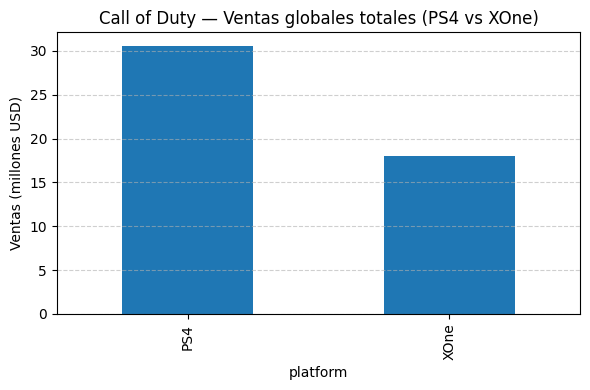

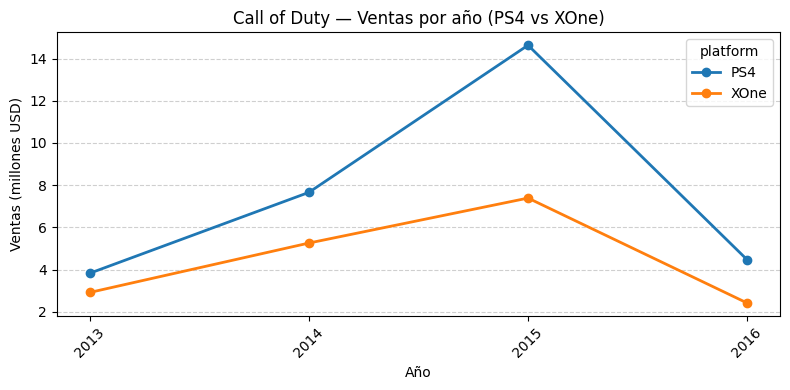

In [61]:
######## sólo para call of duty

# ===== Base de trabajo: periodo reciente si existe, si no todo con df_year =====
base = df_model if 'df_model' in globals() else df_year

# ===== Filtrar Call of Duty en PS4 vs XOne =====
mask_cod   = base['name'].str.contains('call of duty', case=False, na=False)
mask_plat  = base['platform'].isin(['PS4', 'XOne'])
cod_ps_vs_x = base[mask_cod & mask_plat].copy()

# ---------- 1) Barras: ventas totales ----------
totals = (cod_ps_vs_x.groupby('platform')['global_sales']
          .sum()
          .reindex(['PS4','XOne']))  # orden fijo

totals.plot(kind='bar', figsize=(6,4), title='Call of Duty — Ventas globales totales (PS4 vs XOne)')
plt.ylabel('Ventas (millones USD)')
plt.grid(True, axis='y', linestyle='--', linewidth=0.8, alpha=0.6)
plt.tight_layout(); plt.show()

# ---------- 2) Líneas: ventas por año ----------
annual = (cod_ps_vs_x.groupby(['year_of_release','platform'])['global_sales']
          .sum()
          .unstack()                 # columnas = plataformas
          .reindex(columns=['PS4','XOne']))  # asegura el orden/columnas

annual.plot(figsize=(8,4), marker='o', linewidth=2,
            title='Call of Duty — Ventas por año (PS4 vs XOne)')
plt.xlabel('Año'); plt.ylabel('Ventas (millones USD)')
years = annual.index.to_numpy()
step = 2 if len(years) > 20 else 1
plt.xticks(years[::step], rotation=45)
plt.grid(True, axis='y', linestyle='--', linewidth=0.8, alpha=0.6)
plt.tight_layout(); plt.show()


La diferencia entre Xbox One y PS4 en ventas de Call of Duty pudo ser ocasionada por el trato de exclusividad de Play Station. 
